# A multi-cavity module

A single cavity is rarely what you install. This notebook builds a beam line
holding two two-cell cavities — input pipe, taper, bellows, the two
cavities, taper, absorber — and treats it as one structure: one mesh, one
eigenproblem, one set of parameters.

The cavities are not solved in isolation and added up: the solve finds the modes
of the whole line. Two nominally identical cavities do not give one strong mode
each. Sections 4 and 5 show what they give instead, and how to read it.

This notebook is live: every figure below is produced by running `cavsim2d`.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import (Assembly, BLA, Beampipe, Bellows, EllipticalCavity,
                      Taper)
from cavsim2d.utils.style import apply_style, WARM

apply_style()
workspace = tempfile.mkdtemp()

# A TESLA-like mid cell: A, B, a, b, Ri, L, Req  (mm)
MIDCELL = [62.22, 66.13, 30.22, 23.11, 80.0, 93.5, 171.20]
R_IRIS = MIDCELL[4]        # 80 mm - the cavity bore
R_PIPE = 50.0              # the module's external beam pipe

EIG = {'polarisation': 'monopole', 'n_modes': 8,
       'boundary_conditions': 'mm', 'mesh_config': {'h': 12, 'p': 2}}

## 1. Building the module

The external beam pipe is narrower than the cavity bore, so a `Taper` matches
the two at each end rather than leaving an abrupt step. The cavities are built
with `beampipe='both'`, so each carries its own stubs and the two sit some
distance apart — which, as section 4 shows, is what decides whether they behave
as one structure or as two.

In [2]:
def cavity(i):
    return EllipticalCavity(2, MIDCELL, beampipe='both', name=f'cav{i}')


def bellows():
    return Bellows(Ri=R_IRIS, A=12.0, L_p=10.0, N_conv=20,
                   R_root=2.0, R_crest=2.0)


module = Assembly([
    Beampipe(R=R_PIPE, L=120.0, name='bp_in'),
    Taper(R_left=R_PIPE, R_right=R_IRIS, L=80.0, name='taper_in'),
    bellows(),
    cavity(1),
    cavity(2),
    Taper(R_left=R_IRIS, R_right=R_PIPE, L=80.0, name='taper_out'),
    BLA(R=R_PIPE, L=160.0, absorber_length=90.0, absorber_thickness=10.0,
        eps_r=10.0, tan_delta=0.3, maxh=5.0),
], name='module')

print(repr(module))
print(f'length             : {module.length:.0f} mm')
print(f'accelerating cells : {module.n_cells}')
print(f'parameters         : {len(module.parameters)}')

Assembly('module', bp_in + taper_in + bellows + cav1 + cav2 + taper_out + bla, 2136 mm)
length             : 2136 mm
accelerating cells : 4
parameters         : 69


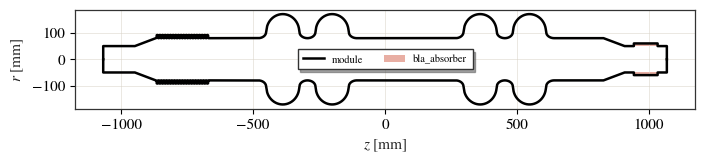

In [3]:
ax = module.plot('geometry', mirror=True, show=False)
ax.legend(loc='center', fontsize=7.5, ncols=2)
plt.show()

## 2. What the module is made of

`offsets()` gives where each element was placed, so an element's own
coordinates can be mapped into module coordinates.

In [4]:
print(f"{'label':12s} {'type':16s} {'starts at':>10s} {'length':>9s}")
print('-' * 51)
for label, el, dz in zip(module.labels, module.elements, module.offsets()):
    zs = [z for z, _ in el.profile().points]
    print(f'{label:12s} {type(el).__name__:16s} '
          f'{dz + min(zs) * 1e3:10.1f} {(max(zs) - min(zs)) * 1e3:9.1f}')

label        type              starts at    length
---------------------------------------------------
bp_in        Beampipe              -60.0     120.0
taper_in     Taper                  60.0      80.0
bellows      Bellows               140.0     200.0
cav1         EllipticalCavity      340.0     748.0
cav2         EllipticalCavity     1088.0     748.0
taper_out    Taper                1836.0      80.0
bla          BLA                  1916.0     160.0


Only the two cavities count as *accelerating cells* — four in total. The pipe,
taper, bellows and absorber are passive, and deliberately do not count: that
cell number is what picks the monopole mode of interest, so letting a bellows
contribute would report the wrong mode of the module.

## 3. The spectrum

Four cells give four modes in the fundamental band. Solve for more than that and
the band, and the gap above it, both show up.

In [5]:
module.set_workspace(os.path.join(workspace, 'module'))
module.eigenmode.run(EIG)

df = module.eigenmode.qois_df
print(df[['mode', 'freq [MHz]', 'R/Q [Ohm]']].to_string(index=False))

 mode  freq [MHz]  R/Q [Ohm]
    0  792.580379   0.011207
    1  792.581130   0.000063
    2  810.989010   1.824535
    3  810.989880 313.080904
    4 1387.704005   0.149301
    5 1453.290358   0.506515
    6 1475.189509   2.021092
    7 1479.984995   0.955539


In [6]:
f = df['freq [MHz]'].to_numpy()
rq = df['R/Q [Ohm]'].to_numpy()
band = f < 1000.0                      # the fundamental band

print(f'{band.sum()} modes below 1 GHz, in two close pairs:')
for lo, hi in ((780, 800), (800, 830)):
    sel = (f > lo) & (f < hi)
    if sel.sum() < 2:
        continue
    print(f'  {f[sel].min():.3f} / {f[sel].max():.3f} MHz'
          f'  -> split {1e3 * (f[sel].max() - f[sel].min()):.2f} kHz,'
          f'  R/Q {rq[sel][0]:.1f} and {rq[sel][1]:.1f} Ohm')

4 modes below 1 GHz, in two close pairs:
  792.580 / 792.581 MHz  -> split 0.75 kHz,  R/Q 0.0 and 0.0 Ohm
  810.989 / 810.990 MHz  -> split 0.87 kHz,  R/Q 1.8 and 313.1 Ohm


Two pairs, each split by under a kilohertz, and within the upper pair one member
holds almost all of the R/Q.

## 4. Looking at the modes

Frequencies alone do not tell you what a mode *is*. `plot_axis_field(mode=...)`
draws the signed accelerating field along the axis for any solved mode, and
that is what makes a spectrum readable: where the lobes sit says which part of
the line a mode lives in, and their relative sign says how the cells are
phased.

`shade_elements(ax)` shades the axial extent of each device behind the curve, so
the field can be read against the hardware. Elements of the same kind share a
colour — both cavities one shade, both tapers another — and a faint rule marks
every boundary, so two like elements in a row stay distinguishable.

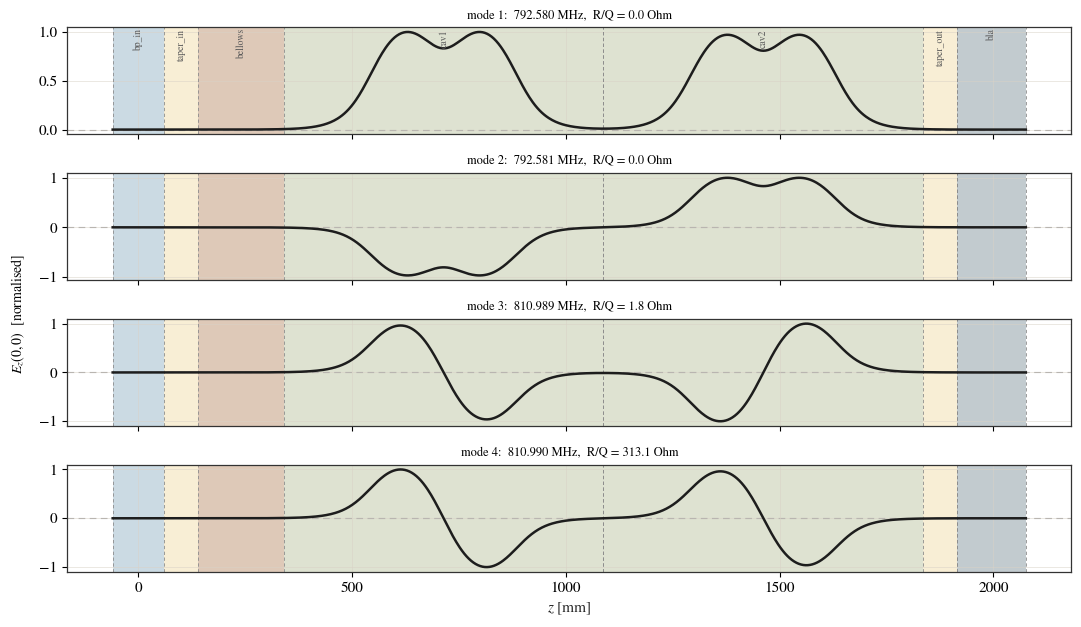

In [7]:
n_band = int(band.sum())
fig, axes = plt.subplots(n_band, 1, figsize=(11, 1.6 * n_band), sharex=True)
for m, ax in enumerate(axes):
    # shade which device occupies which stretch of z; same kind, same colour
    module.shade_elements(ax, legend=False, labels=(m == 0))
    module.plot_axis_field(mode=m, ax=ax, show=False, color='#1d1d1d',
                           label='_nolegend_')
    ax.set_title(f'mode {m + 1}:  {f[m]:.3f} MHz,  R/Q = {rq[m]:.1f} Ohm',
                 fontsize=9)
    ax.set_ylabel('')
    if ax is not axes[-1]:
        ax.set_xlabel('')
fig.supylabel('$E_z(0,0)$  [normalised]', fontsize=10)
plt.tight_layout()
plt.show()

The two modes near 810.99 MHz differ only in the relative phase of the two
cavities:

* the weak one has cavity 1 running `+ -` and cavity 2 running `- +` — out of
  phase, so the voltage one cavity gives the beam is cancelled by the other
  and R/Q collapses to nothing;
* the strong one has both cavities running `+ -` — in phase, so the voltages
  add and R/Q comes out at twice a single cavity.

Neither mode belongs to one cavity: they are the in-phase and out-of-phase
*combinations* of the pair. The 792.58 pair behaves the same way, except that
both of its members are 0-mode-like and neither accelerates.

## 5. Why two cavities do not give two strong modes

With `beampipe='both'` each cavity carries its own stubs, so the two cavity
bodies sit far apart and are barely coupled. Two nominally identical, uncoupled
cavities are degenerate: two modes at the same frequency, here to within a
kilohertz.

In a degenerate pair *any* linear combination of the two is equally valid as an
eigenvector. Here the solver happened to return the clean in-phase and
out-of-phase combinations, which is why the R/Q split so sharply. On a different
mesh it can just as legitimately return two partly-localised combinations and
divide the R/Q, say, 121 / 193 — same structure, same physics, different basis.
So the split between the two members is not a property of the hardware.

What is robust is the sum over the pair. Compare it against one cavity on
its own.

In [8]:
single = EllipticalCavity(2, MIDCELL, beampipe='both', name='single')
single.set_workspace(os.path.join(workspace, 'single'))
single.eigenmode.run({**EIG, 'n_modes': 3})
sdf = single.eigenmode.qois_df
rq_single = sdf['R/Q [Ohm]'].max()
f_single = sdf.loc[sdf['R/Q [Ohm]'].idxmax(), 'freq [MHz]']
print(f'one 2-cell cavity: pi-mode {f_single:.3f} MHz, R/Q = {rq_single:.2f} Ohm')

upper = (f > 800) & (f < 830)
print(f'module, upper pair R/Q  : '
      f"{' + '.join(f'{v:.2f}' for v in rq[upper])} = {rq[upper].sum():.2f} Ohm")
print(f'twice one cavity        : {2 * rq_single:.2f} Ohm')

one 2-cell cavity: pi-mode 810.990 MHz, R/Q = 157.38 Ohm
module, upper pair R/Q  : 1.82 + 313.08 = 314.91 Ohm
twice one cavity        : 314.77 Ohm


The pair carries exactly the R/Q of two cavities, shared between its two
members in a ratio that means nothing. Reading either member on its own — the
313 Ohm one or the 2 Ohm one — would be reading the arbitrary basis, not the
structure.

### Perturbing one cavity decouples them

Detune the second cavity and the degeneracy breaks. Each mode then localises on
a single cavity — the field is flat zero over the other — and each carries that
cavity's own R/Q. *Now* there are two strong modes, at two distinguishable
frequencies, and each one means something on its own.

This is also why field flatness matters in a real module: a fabrication error on
one cavity does not shift the band as a whole, it strands the energy in one
cavity.

In [9]:
print('cavity 2 equator radius :', module.parameters['cav2:Req_m'], 'mm')

module.set_tune_value('cav2:Req', 172.2)          # +1.0 mm, cavity 2 only
module.set_workspace(os.path.join(workspace, 'detuned'))
module.eigenmode.run(EIG)

ddf = module.eigenmode.qois_df
fd = ddf['freq [MHz]'].to_numpy()
rqd = ddf['R/Q [Ohm]'].to_numpy()
strong = rqd > 1.0
print(ddf.loc[strong, ['mode', 'freq [MHz]', 'R/Q [Ohm]']].to_string(index=False))

cavity 2 equator radius : 171.2 mm


 mode  freq [MHz]  R/Q [Ohm]
    2  805.446894 159.442200
    3  810.989638 157.497911
    6 1474.278431   2.208295
    8 1514.419253   1.188477


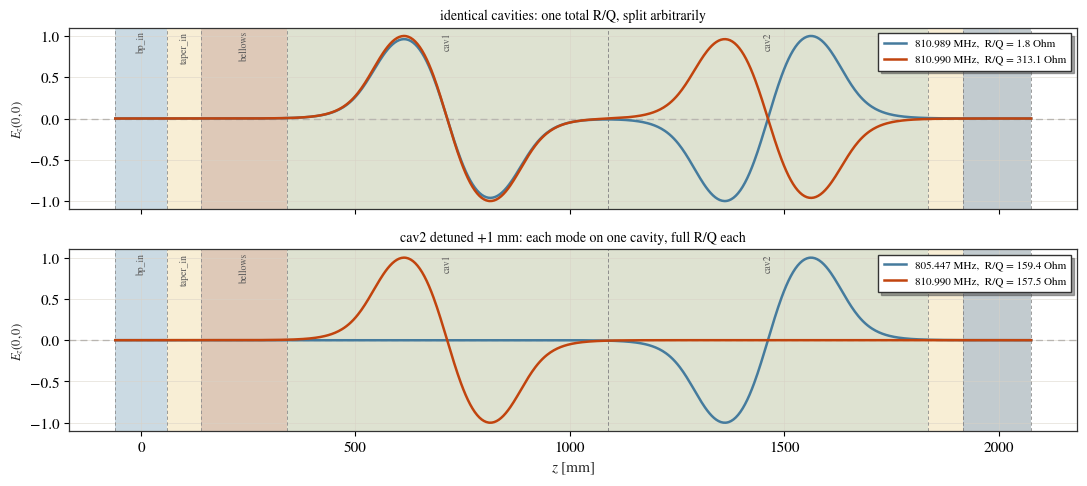

Assembly('module', bp_in + taper_in + bellows + cav1 + cav2 + taper_out + bla, 2136 mm)

In [10]:
top2 = np.argsort(rqd)[-2:]            # the two strong modes of the detuned line
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

for ax in axes:
    module.shade_elements(ax, legend=False)

# nominal: the degenerate pair (fields live in the 'module' workspace)
module.set_workspace(os.path.join(workspace, 'module'))
for m, colour in zip(np.flatnonzero(upper), WARM[:2]):
    module.plot_axis_field(mode=int(m), ax=axes[0], show=False, color=colour,
                           label=f'{f[m]:.3f} MHz,  R/Q = {rq[m]:.1f} Ohm')
axes[0].set_title('identical cavities: one total R/Q, split arbitrarily',
                  fontsize=10)

# detuned: two localised modes
module.set_workspace(os.path.join(workspace, 'detuned'))
for m, colour in zip(sorted(top2), WARM[:2]):
    module.plot_axis_field(mode=int(m), ax=axes[1], show=False, color=colour,
                           label=f'{fd[m]:.3f} MHz,  R/Q = {rqd[m]:.1f} Ohm')
axes[1].set_title('cav2 detuned +1 mm: each mode on one cavity, full R/Q each',
                  fontsize=10)

for ax in axes:
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylabel('$E_z(0,0)$', fontsize=9)
axes[0].set_xlabel('')
plt.tight_layout()
plt.show()

# put the module back the way it was
module.set_tune_value('cav2:Req', 171.20)
module.set_workspace(os.path.join(workspace, 'module'))

## What to take away

* A module is built the same way a single element is, and solved as one
  structure. Parameters are namespaced, so any one cavity is reachable by label.
* Four cells give four modes. `plot_axis_field(mode=...)` is how you tell them
  apart: the signed field shows where a mode lives and how it is phased.
* Identical, weakly coupled cavities give degenerate pairs, not one strong
  mode each. Within a pair the R/Q split between members is arbitrary — only
  the sum is meaningful, and it equals the R/Q of the cavities taken separately.
* Break the degeneracy and the modes separate and localise, each with its own
  full R/Q. Detuning does it; so does coupling the cavities properly, by giving
  them `beampipe='none'` and a short drift so the band spreads over MHz rather
  than kHz.
* Passive elements (pipes, tapers, bellows, absorbers) shape the module without
  counting as cells.

See [Assembling a beam line](beam_line_assembly.ipynb) for the mechanics of
concatenation, and [The bellows element](bellows.ipynb) for the corrugation
itself.